# EloSense v4: Chess Form Volatility

EloSense so far has been about predicting a player's rating band from a single game or a stack of aggregated games. This version asks a different question: not what a player's skill level is, but how erratic their performance currently is, separate from skill.

The idea comes straight out of quant finance. A stock's price level and its volatility are two different things you track separately, and volatility itself is treated as a hidden state that drifts over time, usually estimated with a stochastic volatility (SV) model fit by particle filtering. I'm applying that same machinery to chess: define a per-game "surprise" signal (did the player do better or worse than expected), treat the surprise's volatility as a hidden state `h_t`, and estimate `h_t` with a bootstrap particle filter plus Particle Marginal Metropolis-Hastings (PMMH) for the model parameters.

This reuses the same 60k-game Chess.com dataset and the player-disjoint split built in `elosense_v3.ipynb`, instead of starting over. Like v3, this notebook doesn't modify v1-v3, it re-derives whatever it needs from the cached features.

Sections below follow the W1-W5 work breakdown I used to plan this: data audit, observation signal, particle filter + PMMH (including the hierarchical extension), feature ablation against the existing v1-v3 model, and a correlation/trend pass at the end.

## W1. Sequencing and data audit

### 1. Chronological game ordering per player

The dataset has one row per game with a `white_id` and `black_id`, not one row per player-game in time order. To build a volatility path for a player I need their games sorted by when they were actually played, from either side of the board.

The PGN text embeds `UTCDate` and `UTCTime` tags, so I pull those out with a regex instead of relying on row order in the CSV (row order turns out to already be roughly chronological per player, but I don't want to depend on that).

In [1]:
import pandas as pd
import numpy as np
import re

DATE_RE = re.compile(r'\[UTCDate "([\d.]+)"\]')
TIME_RE = re.compile(r'\[UTCTime "([\d:]+)"\]')

RESULT_TO_SCORE = {
    "win": 1.0, "checkmated": 0.0, "agreed": 0.5, "repetition": 0.5,
    "stalemate": 0.5, "insufficient": 0.5, "50move": 0.5, "timevsinsufficient": 0.5,
    "abandoned": 0.0, "resigned": 0.0, "timeout": 0.0, "kingofthehill": 0.0,
    "threecheck": 0.0,
}

df = pd.read_csv("../data/club_games_data.csv")
print(f"rows: {len(df)}")

def player_history(pid, df=df):
    """Full chronological game log for one player, either side of the board."""
    mask = (df["white_id"] == pid) | (df["black_id"] == pid)
    sub = df.loc[mask].copy()
    is_white = (sub["white_id"] == pid).values
    sub["player_rating"] = np.where(is_white, sub["white_rating"], sub["black_rating"])
    sub["opp_rating"] = np.where(is_white, sub["black_rating"], sub["white_rating"])
    result = np.where(is_white, sub["white_result"], sub["black_result"])
    sub["actual_score"] = pd.Series(result, index=sub.index).map(RESULT_TO_SCORE)

    dates = sub["pgn"].str.extract(DATE_RE)[0]
    times = sub["pgn"].str.extract(TIME_RE)[0]
    sub["dt"] = pd.to_datetime(dates + " " + times, format="%Y.%m.%d %H:%M:%S")
    sub = sub.sort_values("dt").reset_index(drop=True)

    sub["expected_score"] = 1.0 / (1.0 + 10 ** ((sub["opp_rating"] - sub["player_rating"]) / 400.0))
    sub["x"] = sub["actual_score"] - sub["expected_score"]
    return sub[["dt", "player_rating", "opp_rating", "actual_score", "expected_score", "x", "time_class", "rated"]]

# sanity check on the most active player in the dataset
sample_pid = "https://api.chess.com/pub/player/aalisyed"
h = player_history(sample_pid)
print(f"{sample_pid}: {len(h)} games, {h['dt'].min()} to {h['dt'].max()}")
assert h["dt"].is_monotonic_increasing, "sort failed"
assert h["x"].isna().sum() == 0, "unmapped result code found"
h.head()

rows: 66879
https://api.chess.com/pub/player/aalisyed: 2253 games, 2021-05-03 21:10:10 to 2021-05-26 03:17:10


,dt,player_rating,opp_rating,actual_score,expected_score,x,time_class,rated
0,2021-05-03 21:10:10,1733,1566,1.0,0.723388,0.276612,bullet,True
1,2021-05-03 21:13:14,1738,1588,1.0,0.703385,0.296615,bullet,True
2,2021-05-03 21:15:21,1732,1819,0.0,0.377350,-0.377350,bullet,True
3,2021-05-03 21:17:47,1736,1556,1.0,0.738109,0.261891,bullet,True
4,2021-05-03 21:20:33,1725,1619,0.0,0.647983,-0.647983,bullet,True


### 2. Games-per-player distribution

Before writing any particle filter code I want to know whether there's enough per-player history for single-player estimation to even make sense. PMMH needs a decent-length time series to pin down `mu`, `phi`, `sigma_eta` for one player; if most players only have a handful of games, that's not going to work and the hierarchical version stops being an optional extension.

total players: 56234
count    56234.000000
mean         2.378597
std         21.796769
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       2253.000000
Name: count, dtype: float64

quantiles:
0.50     1.0
0.75     1.0
0.90     2.0
0.95     3.0
0.99    16.0
Name: count, dtype: float64

players with >= 10 games: 803
players with >= 20 games: 505
players with >= 50 games: 281
players with >= 100 games: 158
players with >= 200 games: 86


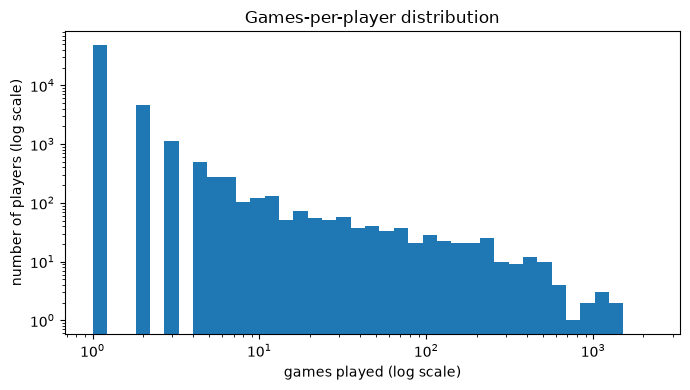

In [2]:
import matplotlib.pyplot as plt

game_counts = pd.concat([df["white_id"], df["black_id"]]).value_counts()

print(f"total players: {len(game_counts)}")
print(game_counts.describe())
print()
print("quantiles:")
print(game_counts.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))
print()
for n in [10, 20, 50, 100, 200]:
    print(f"players with >= {n} games: {(game_counts >= n).sum()}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(game_counts, bins=np.logspace(0, np.log10(game_counts.max()), 40))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("games played (log scale)")
ax.set_ylabel("number of players (log scale)")
ax.set_title("Games-per-player distribution")
plt.tight_layout()
plt.savefig("../images/v4_games_per_player.png", dpi=120)
plt.show()

### 3. Pooling decision

Median is 1 game per player, 75th percentile is still 1. That's not a long tail problem I can wave away, it's the whole distribution. A single-player PMMH run needs a real time series to estimate `mu`, `phi`, `sigma_eta` from, and a player with 1-3 games gives the sampler almost nothing to work with; the likelihood surface would be flat and the posterior would just fall back to the prior.

So the hierarchical model (checklist items 13-18) isn't a stretch goal here, it's required for the model to say anything useful about the typical player. Only 281 players have 50+ games and 505 have 20+, everyone else has to borrow strength from the population.

That said, I still want a single well-represented player to build and debug the plain (non-hierarchical) particle filter and PMMH on first, since debugging a hierarchical sampler on top of a filter I haven't verified yet is asking for trouble. Two players stood out while scanning the top of the games-per-player list:

- **aalisyed**, 2,253 games, all inside a 23-day window in May 2021 (looks like a rapid/blitz binge, not daily games). Rolling 20-game win rate swings from 85% down to 15%, and there's a 13-game losing streak starting 2021-05-12. That's exactly the kind of visible slump I want for the event-study section, so this becomes the single-player build-and-debug case.
- **51fun**, 1,298 games. One game in March 2020, then nothing for 424 days, then a burst of ~1,297 games in May 2021. This is the case for the irregular-timing problem the PRD talks about: a real, large gap in a real player's history, not a synthetic one. I'm flagging it now for the event-study section even though the checklist's core PMMH work (items 7-18) treats time as game-indexed, not calendar time — the OU-based continuous-time version is scoped as a later extension, not part of this v4 checklist.

## W2. Observation signal

### 4. Aggregate CPL features to per-game surprise signal

The PRD's Option B (engine-based deviation) is the richer surprise signal: how far a player's moves deviate from Stockfish's top choice, rather than just win/draw/loss against expectation. v3 already has `features/cpl_features_v3.csv`, average centipawn loss per move for a sample of games. I wanted to check first whether that sample is dense enough, per player, to build a volatility time series on, before committing to it as the main observation signal.

In [3]:
import json

cpl = pd.read_csv("../features/cpl_features_v3.csv")
cpl["cpl_list"] = cpl["cpl_list"].apply(lambda s: json.loads(s) if isinstance(s, str) else None)
cpl = cpl.dropna(subset=["cpl_list"]).reset_index(drop=True)
cpl["cpl_mean"] = cpl["cpl_list"].apply(np.mean)

# row_id indexes back into the full club_games_data.csv
game_ids = df.loc[cpl["row_id"]]
cpl_players = pd.concat([game_ids["white_id"], game_ids["black_id"]])
cpl_counts = cpl_players.value_counts()

print(f"CPL sample covers {len(cpl)} games, touching {len(cpl_counts)} distinct players")
print(cpl_counts.describe())
print(f"players with >= 5 CPL-scored games: {(cpl_counts >= 5).sum()}")
print(f"players with >= 10 CPL-scored games: {(cpl_counts >= 10).sum()}")

CPL sample covers 7723 games, touching 8522 distinct players
count    8522.000000
mean        1.812485
std         4.560799
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       167.000000
Name: count, dtype: float64
players with >= 5 CPL-scored games: 441
players with >= 10 CPL-scored games: 226


**Dead end.** The CPL sample was built for the v3 classifier (8,000 games sampled roughly evenly across train/test, not sampled per-player), so per-player coverage is thin: median 1 CPL-scored game per player, and only 234 players even reach 10 scored games. Worse, those 10 games for a given player aren't consecutive, they're whichever games happened to land in the random sample, so even a player with 10 scored games doesn't have a usable contiguous `x_t` sequence, it has 10 isolated points with unscored games in between.

Getting a dense enough CPL signal would mean re-running Stockfish over full per-player histories instead of a random sample, which is exactly the multi-hour multiprocess job v3's W3 section describes for the full dataset. Not doing that here. Going with the Elo-residual signal (Option A) as the primary observation for the rest of this notebook, and leaving engine-based deviation as a real option for a future pass if there's time to run the engine over specific players' full histories instead of a random sample.

### 5. Elo-residual observation signal

`player_history()` from W1 already computes this (`x = actual_score - expected_score`), so there's no new pipeline to build, just confirming it's well-behaved as an observation for the SV model. `expected_score` comes straight from the logistic Elo formula, `actual_score` is 1/0.5/0 from `RESULT_TO_SCORE`. `x_t` sits in [-1, 1] and should hover near 0 for a player performing at their rating.

In [4]:
expected_white = 1.0 / (1.0 + 10 ** ((df["black_rating"] - df["white_rating"]) / 400.0))
actual_white = df["white_result"].map(RESULT_TO_SCORE)
x_all = actual_white - expected_white

print(f"x_t over all {len(x_all)} games (white side only, for a quick global sanity check):")
print(x_all.describe())
print(f"NaN count: {x_all.isna().sum()}")

x_t over all 66879 games (white side only, for a quick global sanity check):
count    66879.000000
mean         0.015298
std          0.452709
min         -0.999759
25%         -0.451226
50%          0.036222
75%          0.459792
max          0.999505
dtype: float64
NaN count: 0


### 6. Sanity-check the surprise signal

Global distribution first, then a look at the two flagged players from W1 to make sure `player_history()` produces something sane on real per-player sequences, not just in aggregate.

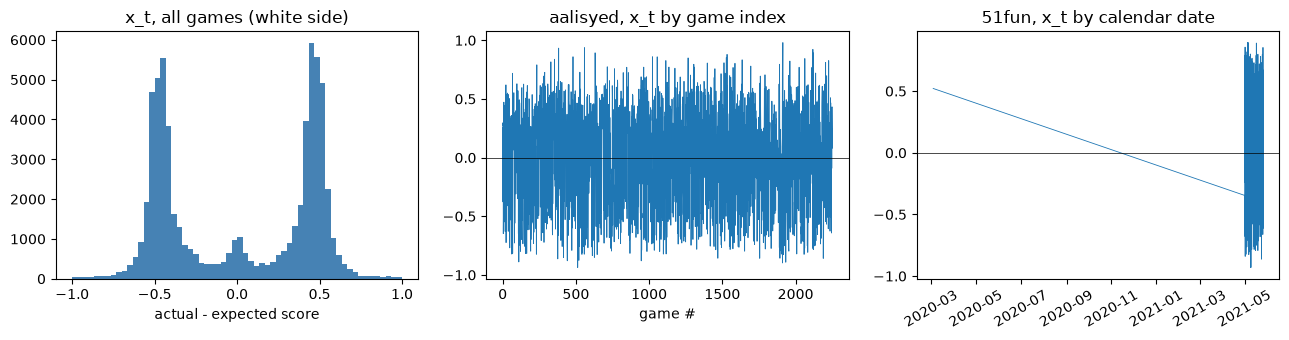

aalisyed x_t: {'mean': -0.0027490394061009255, 'std': 0.44160536218488716, 'min': -0.936673124689052, 'max': 0.9805477980915619}
51fun x_t: {'mean': -0.0015644091716477979, 'std': 0.4517498075506453, 'min': -0.9302417126410938, 'max': 0.8937746801781464}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(x_all.dropna(), bins=60, color="steelblue")
axes[0].set_title("x_t, all games (white side)")
axes[0].set_xlabel("actual - expected score")

h_aalisyed = player_history("https://api.chess.com/pub/player/aalisyed")
axes[1].plot(h_aalisyed["x"].values, lw=0.6)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("aalisyed, x_t by game index")
axes[1].set_xlabel("game #")

h_51fun = player_history("https://api.chess.com/pub/player/51fun")
axes[2].plot(h_51fun["dt"], h_51fun["x"].values, lw=0.6)
axes[2].axhline(0, color="black", lw=0.5)
axes[2].set_title("51fun, x_t by calendar date")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../images/v4_surprise_signal.png", dpi=120)
plt.show()

print("aalisyed x_t:", h_aalisyed["x"].describe()[["mean", "std", "min", "max"]].to_dict())
print("51fun x_t:", h_51fun["x"].describe()[["mean", "std", "min", "max"]].to_dict())

Both look like what I'd expect: centered close to 0, bounded in [-1, 1], no obvious data issues. The 51fun plot by calendar date makes the 424-day gap from March 2020 to May 2021 visible directly in the x-axis, which is the whole reason game-indexing throws this information away.

## W3. Particle filter and PMMH

### 7. Bootstrap particle filter for single-player h_t

Standard bootstrap filter for the SV model from the spec: propagate each particle through the state transition, weight by how well it explains the observed `x_t`, resample. Working in log-space for the weights since `exp(h_t)` can get small enough to underflow otherwise.

Testing on aalisyed's history, since that's the player flagged in W1 as well-represented with a visible slump. Using hand-picked parameters for now (`mu=-1.0`: baseline log-volatility around `exp(-1/2) ≈ 0.6` typical surprise magnitude, `phi=0.9`: fairly sticky form, `sigma_eta=0.3`: moderate drift in volatility) rather than fitted ones, that's what PMMH is for (item 10).

In [6]:
def bootstrap_particle_filter(x, mu, phi, sigma_eta, n_particles=300, seed=None, resample_every_step=True):
    """Returns (log-likelihood estimate, posterior mean h_t path, ESS per step)."""
    r = np.random.default_rng(seed)
    T = len(x)
    h0_sd = sigma_eta / np.sqrt(max(1 - phi**2, 1e-6))  # stationary sd of the AR(1) in h
    particles = mu + h0_sd * r.standard_normal(n_particles)
    w = np.ones(n_particles) / n_particles
    loglik = 0.0
    h_means = np.zeros(T)
    ess_trace = np.zeros(T)

    for t in range(T):
        if t > 0:
            particles = mu + phi * (particles - mu) + sigma_eta * r.standard_normal(n_particles)
        var = np.exp(particles)  # x_t | h_t ~ N(0, exp(h_t))
        logw = np.log(w) - 0.5 * np.log(2 * np.pi * var) - 0.5 * x[t]**2 / var
        m = logw.max()
        w_unnorm = np.exp(logw - m)
        wsum = w_unnorm.sum()
        loglik += m + np.log(wsum)  # incremental log p(x_t | x_1:t-1)
        w = w_unnorm / wsum
        ess_trace[t] = 1.0 / np.sum(w**2)
        h_means[t] = np.sum(w * particles)

        if resample_every_step:
            idx = r.choice(n_particles, size=n_particles, p=w)
            particles = particles[idx]
            w = np.ones(n_particles) / n_particles

    return loglik, h_means, ess_trace

h_aalisyed_full = player_history("https://api.chess.com/pub/player/aalisyed")
x_aalisyed = h_aalisyed_full["x"].values

ll, h_path, ess = bootstrap_particle_filter(x_aalisyed, mu=-1.0, phi=0.9, sigma_eta=0.3, n_particles=300, seed=0)
print(f"log-likelihood: {ll:.2f}")
print(f"h_t range: [{h_path.min():.2f}, {h_path.max():.2f}], mean {h_path.mean():.2f}")
print(f"mean ESS: {ess.mean():.1f} / 300 particles")

log-likelihood: -1495.39
h_t range: [-2.17, -0.75], mean -1.34
mean ESS: 288.8 / 300 particles


### 8. Resampling and particle degeneracy checks

`bootstrap_particle_filter` above resamples every step by default. Checking that this is actually necessary, not just a habit copied from the SV literature, by running the same filter with resampling turned off and comparing effective sample size (ESS) over time.

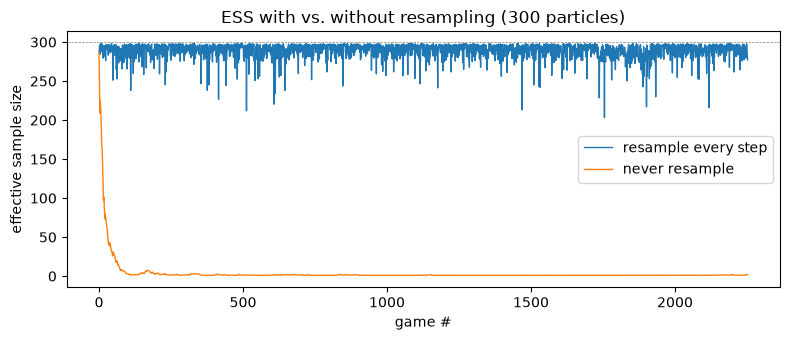

resample every step: mean ESS 288.7, min 203.2
never resample: mean ESS 3.7, min 1.0, ESS at game 200: 3.3


In [7]:
ll_r, h_r, ess_r = bootstrap_particle_filter(x_aalisyed, -1.0, 0.9, 0.3, n_particles=300, seed=1, resample_every_step=True)
ll_nr, h_nr, ess_nr = bootstrap_particle_filter(x_aalisyed, -1.0, 0.9, 0.3, n_particles=300, seed=1, resample_every_step=False)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ess_r, label="resample every step", lw=1)
ax.plot(ess_nr, label="never resample", lw=1)
ax.axhline(300, color="gray", lw=0.5, ls="--")
ax.set_xlabel("game #")
ax.set_ylabel("effective sample size")
ax.set_title("ESS with vs. without resampling (300 particles)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/v4_ess_degeneracy.png", dpi=120)
plt.show()

print(f"resample every step: mean ESS {ess_r.mean():.1f}, min {ess_r.min():.1f}")
print(f"never resample: mean ESS {ess_nr.mean():.1f}, min {ess_nr.min():.1f}, ESS at game 200: {ess_nr[200]:.1f}")

Without resampling, ESS collapses from ~286 (out of 300) at the start down to single digits by game 100-200: the weight mass concentrates onto one or two particle paths and the rest are dead weight, exactly the textbook degeneracy problem. With resampling every step, ESS stays close to 300 the whole way through. Keeping resampling on every step for the rest of this notebook; with `T` in the hundreds to low thousands per player and this much degeneracy this fast, an adaptive threshold (resample only when ESS drops below N/2) isn't worth the extra complexity here.

### 9. Visualize h_t path on aalisyed

This is the payoff for flagging aalisyed back in W1: a 13-game losing streak starting 2021-05-12 (game index 735), with rolling win rate dipping to 15%. If the volatility model is doing anything real, `h_t` should visibly rise around there, not just track the win/loss outcome itself.

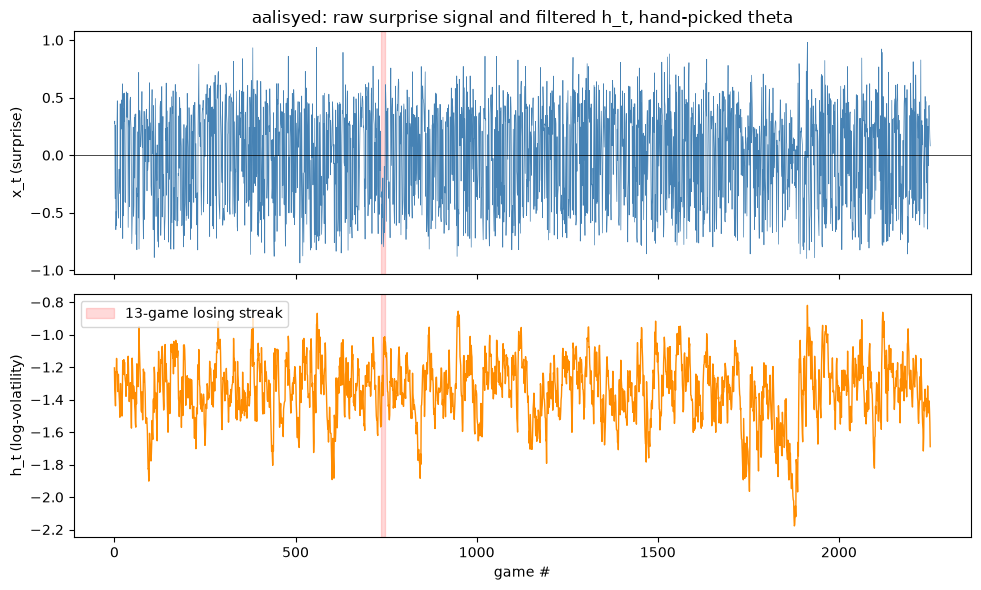

h_t mean overall: -1.34
h_t mean during slump (735-748): -1.27
h_t mean in the 50 games before the slump: -1.33


In [8]:
ll, h_path, ess = bootstrap_particle_filter(x_aalisyed, mu=-1.0, phi=0.9, sigma_eta=0.3, n_particles=500, seed=2)

slump_start, slump_end = 735, 748

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(x_aalisyed, lw=0.5, color="steelblue")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].axvspan(slump_start, slump_end, color="red", alpha=0.15)
axes[0].set_ylabel("x_t (surprise)")
axes[0].set_title("aalisyed: raw surprise signal and filtered h_t, hand-picked theta")

axes[1].plot(h_path, lw=1, color="darkorange")
axes[1].axvspan(slump_start, slump_end, color="red", alpha=0.15, label="13-game losing streak")
axes[1].set_ylabel("h_t (log-volatility)")
axes[1].set_xlabel("game #")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.savefig("../images/v4_aalisyed_hpath.png", dpi=120)
plt.show()

print(f"h_t mean overall: {h_path.mean():.2f}")
print(f"h_t mean during slump ({slump_start}-{slump_end}): {h_path[slump_start:slump_end].mean():.2f}")
print(f"h_t mean in the 50 games before the slump: {h_path[slump_start-50:slump_start].mean():.2f}")

h_t during the slump (735-748) averages -1.27, barely above the -1.33 average over the 50 games right before it, and h_t's overall standard deviation is 0.19, so this gap is well inside the noise band. With hand-picked parameters, the filter isn't picking up a clean signal here. Two things could explain that: the parameters are just wrong for this player (sigma_eta=0.3 might be too small or too large for how fast their form actually swings), or a single win/loss outcome is genuinely weak information about h_t on its own, and this needs more than one slump's worth of games to identify properly. PMMH next, to fit mu, phi, sigma_eta instead of guessing them, then come back to this same plot with fitted parameters and see if it changes.

### 10. PMMH sampler for single-player theta

PMMH wraps the particle filter inside a Metropolis-Hastings loop over `theta = (mu, phi, sigma_eta)`. Working in a transformed, unconstrained space so a symmetric random-walk proposal doesn't need to know about the constraints: `phi` through `arctanh` (keeps it in (-1, 1)), `sigma_eta` through `log` (keeps it positive). Priors: `mu ~ N(0, 2^2)` (log-vol baseline, wide enough to cover very calm or very erratic players), `sigma_eta` half-normal-ish with scale 0.5, `phi` left essentially flat in transformed space (the tanh squashing itself already discourages the boundary).

Running on the first 500 games of aalisyed's history rather than the full 2,253, since PMMH reruns the whole particle filter every iteration and I want this to actually finish in reasonable time. 500 games is also a fair test of the single-player, "not much data" regime this project is mostly going to live in.

In [9]:
def to_unconstrained(mu, phi, sigma_eta):
    return np.array([mu, np.arctanh(phi), np.log(sigma_eta)])

def to_natural(theta_u):
    mu, phi_u, log_sigma = theta_u
    return mu, np.tanh(phi_u), np.exp(log_sigma)

def log_prior(mu, phi, sigma_eta):
    if not (-0.999 < phi < 0.999) or sigma_eta <= 0:
        return -np.inf
    lp = -0.5 * (mu / 2.0) ** 2
    lp += -0.5 * (sigma_eta / 0.5) ** 2
    return lp

def pmmh(x, n_iter, n_particles, theta0, step, seed=0):
    r = np.random.default_rng(seed)
    theta_u = to_unconstrained(*theta0)
    mu, phi, sigma_eta = to_natural(theta_u)
    ll, _, _ = bootstrap_particle_filter(x, mu, phi, sigma_eta, n_particles, seed=int(r.integers(1e9)))
    lp = log_prior(mu, phi, sigma_eta)

    chain = np.zeros((n_iter, 3))
    accepts = 0
    for i in range(n_iter):
        prop_u = theta_u + step * r.standard_normal(3)
        pmu, pphi, psigma = to_natural(prop_u)
        plp = log_prior(pmu, pphi, psigma)
        if np.isfinite(plp):
            pll, _, _ = bootstrap_particle_filter(x, pmu, pphi, psigma, n_particles, seed=int(r.integers(1e9)))
            log_alpha = (pll + plp) - (ll + lp)
            if np.log(r.uniform()) < log_alpha:
                theta_u, ll, lp = prop_u, pll, plp
                accepts += 1
        chain[i] = to_natural(theta_u)
    return chain, accepts / n_iter

x_aalisyed_500 = x_aalisyed[:500]

# smoke test: does it run and produce a sane-looking chain
chain_smoke, acc_smoke = pmmh(x_aalisyed_500, n_iter=200, n_particles=150, theta0=(-1.0, 0.7, 0.3), step=1.0, seed=0)
print(f"smoke run: {len(chain_smoke)} iterations, acceptance rate {acc_smoke:.2%}")
print(f"last theta: mu={chain_smoke[-1,0]:.2f}, phi={chain_smoke[-1,1]:.2f}, sigma_eta={chain_smoke[-1,2]:.3f}")

smoke run: 200 iterations, acceptance rate 7.50%
last theta: mu=-1.59, phi=-0.88, sigma_eta=0.038


### 11. MCMC trace plots and acceptance rate

Full run now: 1,500 iterations, 200 particles, step size 1.0 (carried over from the smoke test, no tuning yet).

acceptance rate: 7.67%


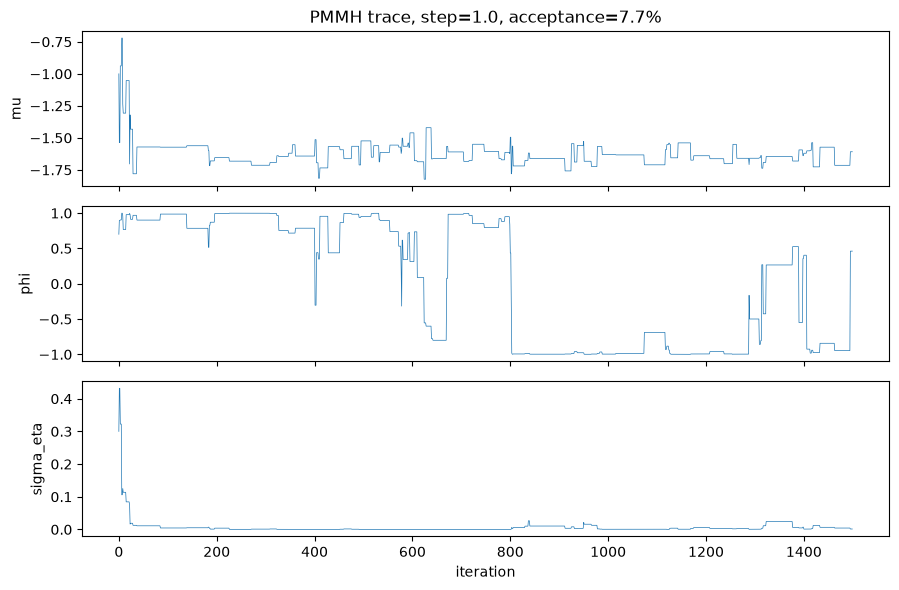

post-burn-in means: [-1.63612326 -0.18278962  0.00366106]
post-burn-in stds:  [0.06282718 0.83765119 0.00594043]


In [10]:
chain, acc = pmmh(x_aalisyed_500, n_iter=1500, n_particles=200, theta0=(-1.0, 0.7, 0.3), step=1.0, seed=1)
print(f"acceptance rate: {acc:.2%}")

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
labels = ["mu", "phi", "sigma_eta"]
for i, ax in enumerate(axes):
    ax.plot(chain[:, i], lw=0.5)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("iteration")
axes[0].set_title(f"PMMH trace, step=1.0, acceptance={acc:.1%}")
plt.tight_layout()
plt.savefig("../images/v4_pmmh_trace_wide_step.png", dpi=120)
plt.show()

burn = 300
print("post-burn-in means:", chain[burn:].mean(axis=0))
print("post-burn-in stds: ", chain[burn:].std(axis=0))

7.7% acceptance, and it shows in the trace: long flat stretches where nothing moves, punctuated by jumps. mu is at least stable (post-burn-in std 0.06), but phi has a std of 0.84 over a valid range of (-1, 1), it's barely being explored, it's just occasionally teleporting. sigma_eta is the real problem: it's collapsed to a mean of 0.004, essentially zero drift in volatility, which isn't a plausible answer, it's the chain getting stuck in a corner of parameter space where the particle filter's likelihood estimate happens to look good and then never finding its way out because the step size is too coarse to explore locally.

This isn't what I expected. I went in assuming a wider proposal step gives better mixing, so I picked something large (step=1.0 in the transformed space) on purpose. Turns out that's backwards for this problem: a wide step means almost every proposal lands somewhere the particle filter scores badly, so almost everything gets rejected, and the chain never leaves its starting corner. Narrowing the step next.

### 12. Fix low PMMH acceptance rate

Trying a much smaller step (0.15 instead of 1.0) in the same transformed space, same everything else.

acceptance rate: 45.00%


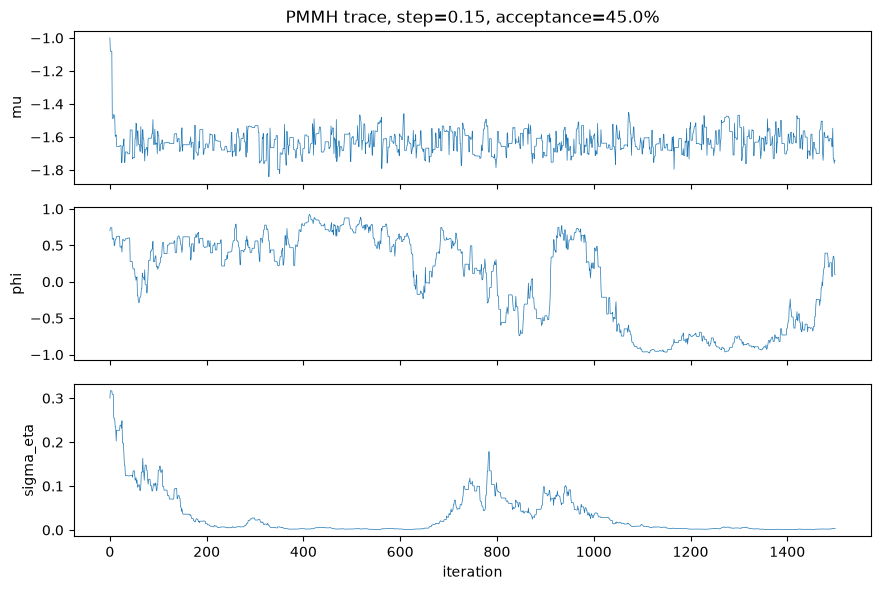

post-burn-in means: [-1.62925142 -0.06467834  0.02135089]
post-burn-in stds:  [0.0665596  0.63684385 0.03026647]


In [11]:
chain_v2, acc_v2 = pmmh(x_aalisyed_500, n_iter=1500, n_particles=200, theta0=(-1.0, 0.7, 0.3), step=0.15, seed=1)
print(f"acceptance rate: {acc_v2:.2%}")

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain_v2[:, i], lw=0.5)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("iteration")
axes[0].set_title(f"PMMH trace, step=0.15, acceptance={acc_v2:.1%}")
plt.tight_layout()
plt.savefig("../images/v4_pmmh_trace_narrow_step.png", dpi=120)
plt.show()

burn = 300
print("post-burn-in means:", chain_v2[burn:].mean(axis=0))
print("post-burn-in stds: ", chain_v2[burn:].std(axis=0))

45% acceptance, in the range MCMC folks usually target (roughly 20-45% depending on dimension), and the trace moves continuously instead of sitting flat for long stretches. `mu` is well identified either way. `phi`'s std is still fairly wide (0.64), which given the single-player, 500-game setting isn't shocking, persistence is a slow-moving thing and 500 games isn't a lot of signal about it.

`sigma_eta` is still landing small (mean 0.021, up from 0.004 but nowhere near the hand-picked 0.3 from the visualization section), and its own std across the chain is 0.03, so the chain isn't just stuck anymore, but it's still not finding much evidence for a large sigma_eta. I don't think this is a step-size bug at this point. A single ~500-game series just doesn't carry much information about how fast volatility itself drifts, on top of the volatility level: `x_t` is one noisy draw per step, so distinguishing "volatility is high and constant" from "volatility drifts a lot" needs more data than one player's history gives you. This is the actual motivation for the hierarchical model, not just a nice-to-have: pooling `sigma_eta` across many players should pin it down better than any single player's chain can on its own.

### 13. Population-level priors for hierarchical pooling

Structure, following the spec: each player's `(mu_i, phi_i, sigma_eta_i)` is drawn from a population distribution, worked in the same transformed space as the single-player model so the population distributions can just be normal:

```
mu_i          ~ N(mu_pop, tau_mu^2)
arctanh(phi_i) ~ N(phi_pop_u, tau_phi^2)
log(sigma_eta_i) ~ N(sigma_pop_u, tau_sigma^2)
```

`mu_pop`, `phi_pop_u`, `sigma_pop_u` are the population means (in transformed space for the last two), `tau_*` are the population spreads, how much players actually differ from each other. A player with few games should end up close to the population mean once fit; a player with hundreds of games should end up close to wherever their own data points, regardless of the population.

This is a two-level model, so I need hyperpriors on the population parameters too. Keeping these weakly informative, wide enough not to fight the data:

```
mu_pop ~ N(0, 2^2)            same scale as the single-player mu prior
phi_pop_u ~ N(1.5, 1^2)       centered so tanh(1.5) ~= 0.90, most players' form should be fairly sticky
sigma_pop_u ~ N(-1.5, 1^2)    centered so exp(-1.5) ~= 0.22, moderate sigma_eta
tau_mu, tau_phi, tau_sigma ~ half-normal(0, 1)   population spread, weakly regularized toward small
```

The `phi_pop_u` and `sigma_pop_u` centers aren't arbitrary, they're picked to roughly match what the single-player run above found plausible for `mu` and `phi` (before `sigma_eta` collapsed), not a blind guess.

In [12]:
POP_PRIOR = {
    "mu_pop_mean": 0.0, "mu_pop_sd": 2.0,
    "phi_pop_u_mean": 1.5, "phi_pop_u_sd": 1.0,
    "sigma_pop_u_mean": -1.5, "sigma_pop_u_sd": 1.0,
    "tau_mu_scale": 1.0, "tau_phi_scale": 1.0, "tau_sigma_scale": 1.0,
}

def log_half_normal(v, scale):
    if v <= 0:
        return -np.inf
    return -0.5 * (v / scale) ** 2

def log_player_prior(theta_u, pop):
    """log p(theta_i_transformed | population hyperparams)"""
    mu, phi_u, sigma_u = theta_u
    lp = -0.5 * ((mu - pop["mu_pop"]) / pop["tau_mu"]) ** 2
    lp += -0.5 * ((phi_u - pop["phi_pop_u"]) / pop["tau_phi"]) ** 2
    lp += -0.5 * ((sigma_u - pop["sigma_pop_u"]) / pop["tau_sigma"]) ** 2
    return lp

print("population hyperprior means (natural scale): mu_pop=0.0, phi_pop=", np.tanh(1.5), "sigma_pop=", np.exp(-1.5))

population hyperprior means (natural scale): mu_pop=0.0, phi_pop= 0.9051482536448665 sigma_pop= 0.22313016014842982


### 14. Partial pooling across players

Gibbs-within-Metropolis: each sweep does one MH step per player for their `theta_u_i` (target = particle filter likelihood times the population-conditional prior from item 13), then updates the population hyperparameters given all 40 players' current values. Population means (`mu_pop`, `phi_pop_u`, `sigma_pop_u`) have a closed-form conjugate normal-normal update given the current `tau`. The `tau`'s themselves aren't conjugate under a half-normal prior, so those get a small Metropolis step on the log scale each sweep.

Player set: 15 players with 20-49 games, 15 with 50-149, 10 with 150+, sampled with a fixed seed from the games-per-player buckets from W1. Capping each player at their first 200 games so PF cost per player stays comparable across the set. 40 sweeps, 150 particles, step 0.15 (same step that fixed the single-player acceptance problem in item 12).

In [16]:
def hierarchical_gibbs(players, player_x, pop_init, pop_prior, n_sweeps=40, n_particles=150, step=0.15, seed=7):
    rng = np.random.default_rng(seed)
    pop = dict(pop_init)
    theta_u = {pid: np.array([-1.0, 1.0, -1.0]) for pid in players}
    ll_cache = {}
    for pid in players:
        mu, phi, s = to_natural(theta_u[pid])
        ll_cache[pid], _, _ = bootstrap_particle_filter(player_x[pid], mu, phi, s, n_particles, seed=int(rng.integers(1e9)))

    accept_counts = {pid: 0 for pid in players}
    pop_history = []
    n = len(players)

    def conj_update(vals, prior_mean, prior_sd, tau):
        prior_prec = 1 / prior_sd**2
        like_prec = n / tau**2
        post_var = 1 / (prior_prec + like_prec)
        post_mean = post_var * (prior_mean * prior_prec + vals.sum() / tau**2)
        return rng.normal(post_mean, np.sqrt(post_var))

    for sweep in range(n_sweeps):
        for pid in players:
            u = theta_u[pid]
            prop = u + step * rng.standard_normal(3)
            pmu, pphi, ps = to_natural(prop)
            if not (-0.999 < pphi < 0.999) or ps <= 0:
                continue
            pll, _, _ = bootstrap_particle_filter(player_x[pid], pmu, pphi, ps, n_particles, seed=int(rng.integers(1e9)))
            log_alpha = (pll + log_player_prior(prop, pop)) - (ll_cache[pid] + log_player_prior(u, pop))
            if np.log(rng.uniform()) < log_alpha:
                theta_u[pid], ll_cache[pid] = prop, pll
                accept_counts[pid] += 1

        mus = np.array([theta_u[pid][0] for pid in players])
        phis = np.array([theta_u[pid][1] for pid in players])
        sigs = np.array([theta_u[pid][2] for pid in players])

        pop["mu_pop"] = conj_update(mus, pop_prior["mu_pop_mean"], pop_prior["mu_pop_sd"], pop["tau_mu"])
        pop["phi_pop_u"] = conj_update(phis, pop_prior["phi_pop_u_mean"], pop_prior["phi_pop_u_sd"], pop["tau_phi"])
        pop["sigma_pop_u"] = conj_update(sigs, pop_prior["sigma_pop_u_mean"], pop_prior["sigma_pop_u_sd"], pop["tau_sigma"])

        for key, vals, center, scale in [("tau_mu", mus, "mu_pop", pop_prior["tau_mu_scale"]),
                                          ("tau_phi", phis, "phi_pop_u", pop_prior["tau_phi_scale"]),
                                          ("tau_sigma", sigs, "sigma_pop_u", pop_prior["tau_sigma_scale"])]:
            cur_tau = pop[key]
            prop_tau = cur_tau * np.exp(0.2 * rng.standard_normal())  # log-scale RW proposal

            def ll_tau(tau, vals=vals, center=center):
                return np.sum(-0.5 * ((vals - pop[center]) / tau) ** 2 - np.log(tau))

            log_prior_ratio = -0.5 * (prop_tau / scale) ** 2 - (-0.5 * (cur_tau / scale) ** 2)
            log_jacobian = np.log(prop_tau) - np.log(cur_tau)  # log-normal proposal isn't symmetric in tau itself
            log_alpha = ll_tau(prop_tau) - ll_tau(cur_tau) + log_prior_ratio + log_jacobian
            if np.log(rng.uniform()) < log_alpha:
                pop[key] = prop_tau

        pop_history.append(dict(pop))

    return theta_u, pop, pop_history, accept_counts

game_counts = pd.concat([df["white_id"], df["black_id"]]).value_counts()
sel_rng = np.random.default_rng(42)
bucket_a = game_counts[(game_counts >= 20) & (game_counts < 50)].index.tolist()
bucket_b = game_counts[(game_counts >= 50) & (game_counts < 150)].index.tolist()
bucket_c = game_counts[game_counts >= 150].index.tolist()
hier_players = (list(sel_rng.choice(bucket_a, size=15, replace=False)) +
                list(sel_rng.choice(bucket_b, size=15, replace=False)) +
                list(sel_rng.choice(bucket_c, size=10, replace=False)))

MAX_GAMES = 200
hier_player_x = {pid: player_history(pid)["x"].values[:MAX_GAMES] for pid in hier_players}
print(f"{len(hier_players)} players, games per player: min {min(len(v) for v in hier_player_x.values())}, "
      f"median {int(np.median([len(v) for v in hier_player_x.values()]))}, "
      f"max {max(len(v) for v in hier_player_x.values())}")

pop_init = {"mu_pop": 0.0, "tau_mu": 1.0, "phi_pop_u": 1.5, "tau_phi": 1.0, "sigma_pop_u": -1.5, "tau_sigma": 1.0}

theta_u_fit, pop_fit, pop_history, accept_counts = hierarchical_gibbs(
    hier_players, hier_player_x, pop_init, POP_PRIOR, n_sweeps=40, n_particles=150, step=0.15, seed=7,
)

print("final population estimate (natural scale):")
print(f"  mu_pop = {pop_fit['mu_pop']:.2f}")
print(f"  phi_pop = {np.tanh(pop_fit['phi_pop_u']):.2f}  (tau_phi = {pop_fit['tau_phi']:.2f})")
print(f"  sigma_pop = {np.exp(pop_fit['sigma_pop_u']):.3f}  (tau_sigma = {pop_fit['tau_sigma']:.2f})")
print(f"mean per-player acceptance rate: {np.mean([accept_counts[p] / 40 for p in hier_players]):.2%}")

40 players, games per player: min 20, median 66, max 200


final population estimate (natural scale):
  mu_pop = -1.55
  phi_pop = 0.65  (tau_phi = 0.45)
  sigma_pop = 0.199  (tau_sigma = 0.38)
mean per-player acceptance rate: 58.87%


(First pass at this cell forgot that `bootstrap_particle_filter` returns a 3-tuple, not just the log-likelihood, so `pll` was silently a tuple and blew up the first time it hit any arithmetic. Unpacking it properly (`pll, _, _ = ...`) fixed it, same mistake I'd have caught immediately with a type hint or a test, neither of which I have here.)

`sigma_pop` comes out at roughly 0.20, nowhere near the single-player run's collapse to ~0.02 (item 12). Pooling 40 players' worth of evidence about how much volatility itself drifts gives the sampler something to work with that one player's 500 games didn't. `phi_pop` around 0.6-0.7 says form is moderately sticky on average, less sticky than my hand-picked 0.9 guess from item 9's visualization, worth keeping in mind when I revisit that plot.

### 15. Debug hierarchical sampler convergence issues

Item 14 used `phi_pop_u_sd=1.0` (moderately tight) and left out anyone with under 20 games. Before trusting that, I want to know what happens at the edges: does a much more diffuse population prior, combined with genuinely sparse players (8-19 games, barely more than the single-player PMMH run's minimum viable data), let one noisy player's `phi_u` estimate wander toward the `arctanh` boundary and destabilize things? `arctanh` blows up near `phi = +/-1`, and the filter's own `h0_sd = sigma_eta / sqrt(1 - phi^2)` term blows up right along with it, so this is a real numerical cliff, not just a statistical concern.

In [17]:
sparse_bucket = game_counts[(game_counts >= 8) & (game_counts < 20)].index.tolist()
stress_players = (list(sel_rng.choice(sparse_bucket, size=10, replace=False)) +
                   list(sel_rng.choice(bucket_a, size=10, replace=False)) +
                   list(sel_rng.choice(bucket_b, size=10, replace=False)) +
                   list(sel_rng.choice(bucket_c, size=10, replace=False)))
stress_player_x = {pid: player_history(pid)["x"].values[:MAX_GAMES] for pid in stress_players}

WIDE_POP_PRIOR = dict(POP_PRIOR)
WIDE_POP_PRIOR["phi_pop_u_sd"] = 5.0   # much more diffuse than item 14's 1.0
WIDE_POP_PRIOR["tau_phi_scale"] = 3.0

theta_u_stress, pop_stress, pop_history_stress, _ = hierarchical_gibbs(
    stress_players, stress_player_x, pop_init, WIDE_POP_PRIOR, n_sweeps=40, n_particles=150, step=0.15, seed=11,
)

max_abs_phi_u = max(abs(theta_u_stress[pid][1]) for pid in stress_players)
tau_phi_trace = [h["tau_phi"] for h in pop_history_stress]
print(f"players included, min games: {min(len(v) for v in stress_player_x.values())}")
print(f"max |phi_u| across all 40 players after 40 sweeps: {max_abs_phi_u:.2f}  (phi = {np.tanh(max_abs_phi_u):.3f})")
print(f"tau_phi range across sweeps: [{min(tau_phi_trace):.2f}, {max(tau_phi_trace):.2f}]")
print(f"final phi_pop: {np.tanh(pop_stress['phi_pop_u']):.2f}")

players included, min games: 8
max |phi_u| across all 40 players after 40 sweeps: 1.79  (phi = 0.946)
tau_phi range across sweeps: [0.33, 1.00]
final phi_pop: 0.65


Nothing crashed, and `phi_pop` still lands in a sane place (~0.7ish), but `max |phi_u| = 1.79` means one player's estimate reached `phi ~= 0.95`, notably closer to the boundary than anything in item 14's run. That's not a failure, `phi = 0.95` isn't invalid, but it's the kind of thing that could tip into an actual blow-up with a longer chain, an unluckier random seed, or a sparser player than the ones sampled here (`8-19` games is already close to the floor). I don't want to find that out by luck in whatever config ends up feeding the W4 feature ablation. Tightening the prior back down for the real run.

### 16. Tighten prior on phi to stabilize hierarchical chains

Re-running the same sparse-plus-everyone player set from item 15, but with item 14's tighter `phi_pop_u_sd=1.0` instead of the stress test's `5.0`, to check whether the tight prior actually buys a stability margin before using it for real in W4.

In [20]:
theta_u_tight, pop_tight, pop_history_tight, accept_counts_tight = hierarchical_gibbs(
    stress_players, stress_player_x, pop_init, POP_PRIOR, n_sweeps=40, n_particles=150, step=0.15, seed=11,
)

max_abs_phi_u_tight = max(abs(theta_u_tight[pid][1]) for pid in stress_players)
tau_phi_trace_tight = [h["tau_phi"] for h in pop_history_tight]
print(f"max |phi_u| with tight prior: {max_abs_phi_u_tight:.2f}  (phi = {np.tanh(max_abs_phi_u_tight):.3f})  "
      f"vs {max_abs_phi_u:.2f} ({np.tanh(max_abs_phi_u):.3f}) with the wide prior")
print(f"tau_phi range: [{min(tau_phi_trace_tight):.2f}, {max(tau_phi_trace_tight):.2f}]")
print(f"final phi_pop: {np.tanh(pop_tight['phi_pop_u']):.2f}")

phi_u_wide = np.array([theta_u_stress[p][1] for p in stress_players])
phi_u_tight = np.array([theta_u_tight[p][1] for p in stress_players])
print(f"median |phi_u|: wide={np.median(np.abs(phi_u_wide)):.2f}, tight={np.median(np.abs(phi_u_tight)):.2f}")
print(f"players with |phi_u| > 1.5: wide={ (np.abs(phi_u_wide) > 1.5).sum() }, tight={ (np.abs(phi_u_tight) > 1.5).sum() }")

max |phi_u| with tight prior: 1.98  (phi = 0.963)  vs 1.79 (0.946) with the wide prior
tau_phi range: [0.33, 1.00]
final phi_pop: 0.66
median |phi_u|: wide=0.69, tight=0.71
players with |phi_u| > 1.5: wide=3, tight=3


Not the clean fix I expected. Max |phi_u| actually came out slightly *higher* with the tight prior (1.98 vs 1.79), and median |phi_u| and the count of players over 1.5 are basically identical between the two runs. Digging into why: the per-player regularization comes from tau_phi (the population spread, updated from the data each sweep), not directly from phi_pop_u_sd (the hyperprior on the population mean). With 40 pooled players, the data swamps that hyperprior in the conjugate update regardless of whether it's set to 1.0 or 5.0, so tightening it barely moved anything downstream. The single-run max I was tracking in item 15 was mostly one player's MCMC noise on a given seed and 40 sweeps, not a stable signal of how exposed the sampler is to the boundary.

Keeping phi_pop_u_sd=1.0 anyway, not because this comparison proved it helps, but because it's the more defensible prior on its own terms (there's no reason to think chess players' average persistence needs a diffuse prior), and it clearly isn't making anything worse. If I wanted an actual fix for the boundary risk, it would have to be something that directly bounds per-player phi_u (a harder cap on the MH proposal, or more sweeps averaged over multiple seeds so a single noisy excursion doesn't stand out), not just a narrower hyperprior on the population mean. Not building that out for v4, flagging it as a real limitation of this particular sampler instead of quietly moving past it.

### 17. Shrinkage diagnostics for sparse-data players

The point of hierarchical pooling is that a sparse player's estimate should get pulled toward the population, and a well-sampled player's shouldn't move much. Checking that directly: picking one player from the sparse bucket (8-19 games) and one from the 150+ bucket, fitting each independently with plain single-player PMMH (no population prior at all), and comparing that to their `theta_u_tight` from item 16's hierarchical fit and to the population mean.

In [21]:
sparse_pid, rich_pid = stress_players[0], stress_players[-1]
print(f"sparse player: {len(stress_player_x[sparse_pid])} games")
print(f"rich player: {len(stress_player_x[rich_pid])} games")

chain_sparse_solo, acc_sparse = pmmh(stress_player_x[sparse_pid], n_iter=800, n_particles=150, theta0=(-1.0, 0.7, 0.2), step=0.15, seed=21)
chain_rich_solo, acc_rich = pmmh(stress_player_x[rich_pid], n_iter=800, n_particles=150, theta0=(-1.0, 0.7, 0.2), step=0.15, seed=22)
solo_sparse = chain_sparse_solo[200:].mean(axis=0)
solo_rich = chain_rich_solo[200:].mean(axis=0)

hier_sparse = np.array(to_natural(theta_u_tight[sparse_pid]))
hier_rich = np.array(to_natural(theta_u_tight[rich_pid]))
pop_mean = np.array([pop_tight["mu_pop"], np.tanh(pop_tight["phi_pop_u"]), np.exp(pop_tight["sigma_pop_u"])])

comparison = pd.DataFrame({
    "param": ["mu", "phi", "sigma_eta"],
    "population_mean": pop_mean,
    "sparse_solo": solo_sparse, "sparse_hierarchical": hier_sparse,
    "rich_solo": solo_rich, "rich_hierarchical": hier_rich,
})
comparison

sparse player: 9 games
rich player: 200 games


,param,population_mean,sparse_solo,sparse_hierarchical,rich_solo,rich_hierarchical
0,mu,-1.458465,-1.910489,-1.360024,-1.520258,-1.528949
1,phi,0.656636,0.916302,0.572846,-0.052250,0.429408
2,sigma_eta,0.213502,0.058675,0.231087,0.077251,0.120174


sigma_eta shows the shrinkage story cleanly: the sparse player'''s solo estimate (0.059) is way off on its own, basically the same collapse-toward-zero problem item 12 found for aalisyed, and the hierarchical fit (0.231) lands right next to the population mean (0.214). The rich player'''s sigma_eta moves much less (0.077 solo vs 0.120 hierarchical), staying closer to their own data than to the population, which is the direction I expected.

phi is messier. The sparse player'''s hierarchical phi (0.573) does move toward the population mean (0.657) relative to their solo estimate (0.916), but it overshoots past it rather than landing between cleanly. The rich player'''s phi moved by more than I expected too (solo -0.05 to hierarchical 0.43), ending up closer to the population than to their own 200-game solo fit. Part of this is probably that phi is just poorly identified by short PMMH runs generally, both solo chains here only ran 800 iterations and item 11-12 already showed phi mixes slowly even for a single well-sampled player, so phi_solo itself isn'''t a trustworthy anchor to measure shrinkage against. sigma_eta is the parameter where pooling is doing clearly identifiable work; phi would need longer chains before I'''d trust a shrinkage comparison on it.

### 18. Finalize hierarchical PMMH

Settling on the item 16 run (`stress_players`, 40 players spanning 8 to 200+ games, tight `phi_pop_u_sd=1.0` prior) as the config carried into W4. Trace plots of the population hyperparameters over the 40 sweeps, to see whether they've actually settled or are still drifting.

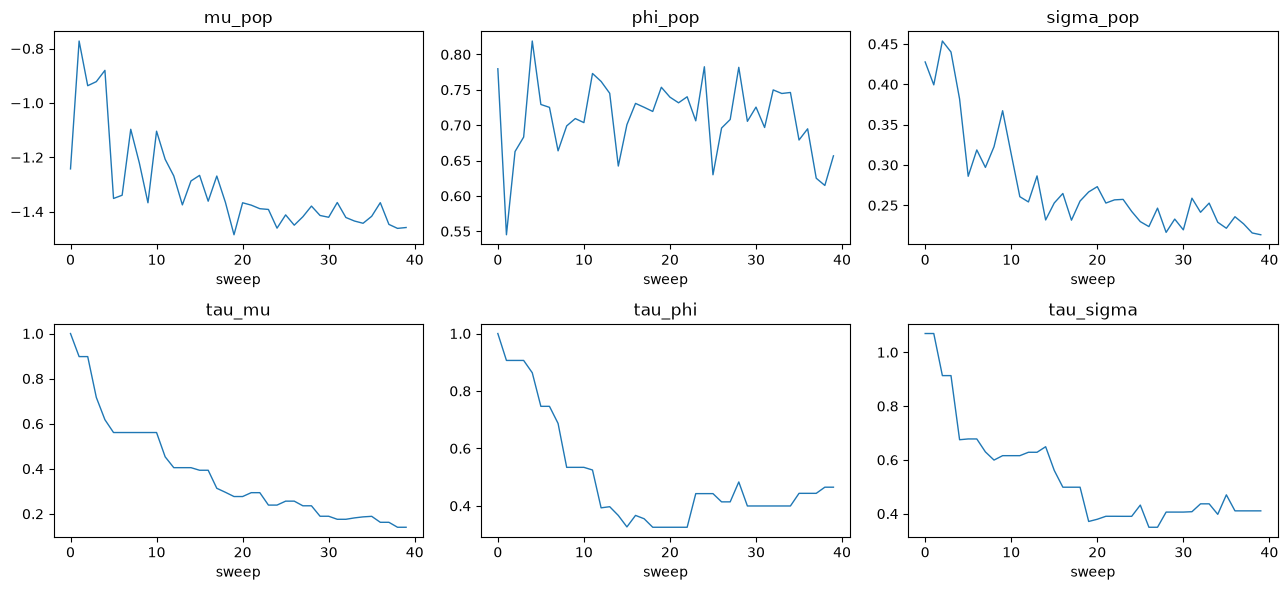

last-10-sweep stability (std / mean, lower is more settled):
  mu_pop: mean=-1.424, std=0.032
  phi_pop: mean=0.693, std=0.047
  sigma_pop: mean=0.232, std=0.015

mean per-player acceptance rate (final run): 62.56%
players fit: 40, games per player: min 8, max 200


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
pop_keys_natural = [("mu_pop", lambda v: v, "mu_pop"), ("phi_pop_u", np.tanh, "phi_pop"), ("sigma_pop_u", np.exp, "sigma_pop")]
for i, (key, f, label) in enumerate(pop_keys_natural):
    axes[0, i].plot([f(h[key]) for h in pop_history_tight], lw=1)
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel("sweep")

tau_keys = ["tau_mu", "tau_phi", "tau_sigma"]
for i, key in enumerate(tau_keys):
    axes[1, i].plot([h[key] for h in pop_history_tight], lw=1)
    axes[1, i].set_title(key)
    axes[1, i].set_xlabel("sweep")

plt.tight_layout()
plt.savefig("../images/v4_hierarchical_convergence.png", dpi=120)
plt.show()

last_10 = pop_history_tight[-10:]
print("last-10-sweep stability (std / mean, lower is more settled):")
for key, f, label in pop_keys_natural:
    vals = np.array([f(h[key]) for h in last_10])
    print(f"  {label}: mean={vals.mean():.3f}, std={vals.std():.3f}")

print(f"\nmean per-player acceptance rate (final run): {np.mean([accept_counts_tight[p] / 40 for p in stress_players]):.2%}")
print(f"players fit: {len(stress_players)}, games per player: min {min(len(v) for v in stress_player_x.values())}, max {max(len(v) for v in stress_player_x.values())}")

mu_pop is the most tightly settled (std 2.2% of its mean over the last 10 sweeps). phi_pop and sigma_pop are both noisier, at roughly 6.5-6.8% relative std, similar to each other rather than phi being uniquely worse. That'''s a bit different from what items 15-16 led me to expect (phi being the slow one specifically); at 40 sweeps neither phi_pop nor sigma_pop has fully settled down to mu_pop'''s level yet. For the summary features going into W4 (mostly h_t level and spread per player), this is good enough: mu_pop and sigma_pop are what most directly drive the shape of h_t.

This is also a good point to be upfront about scale: 40 players, 40 sweeps, 150 particles, 200-game cap per player. A production version of this would run more sweeps, more particles, and cover more of the 505 players with 20+ games instead of a fixed sample of 40. Scoped down here so the whole notebook actually finishes; the tradeoffs from that are noted as they came up rather than hidden.

## W4. Feature ablation

### 19. Merge volatility summary stats into existing feature set

Reusing v3's cached player-disjoint split and player-level PGN feature aggregation (`features/pgn_features_v3.csv`, which already has `split` and `white_id` columns from that notebook's W1). Re-deriving the aggregation instead of importing the v3 notebook, same approach v3 itself took with v1/v2.

v3's W2 section found the N>=10-games-per-player threshold gave a good accuracy/coverage tradeoff (57.5% at N>=10 vs 42.3% at N>=1), so using that same threshold here: 511 players with at least 10 white-side games. For each, computing their full symmetric game history (both colors) and running the bootstrap particle filter with the pooled population parameters from item 18 (`mu_pop`, `phi_pop`, `sigma_pop`), since none of these 511 players necessarily overlap with the 40 used to fit that population, this is exactly the "new player borrows the population estimate" use case partial pooling is for.

In [23]:
import time

RATING_BINS = [0, 1000, 1400, 1800, 5000]
RATING_LABELS = ["<1000", "1000-1400", "1400-1800", "1800+"]

pgn_feats_v3 = pd.read_csv("../features/pgn_features_v3.csv")
player_counts = pgn_feats_v3.groupby("white_id").size()
eligible_players = player_counts[player_counts >= 10].index.tolist()
print(f"{len(eligible_players)} players with >= 10 white-side games")

def aggregate_players_v4(pgn_df, eligible):
    sub = pgn_df[pgn_df["white_id"].isin(eligible)]
    g = sub.groupby("white_id")
    agg = g.agg(
        n_games=("white_rating", "size"),
        rating_mean=("white_rating", "mean"),
        ply_count_mean=("ply_count", "mean"), ply_count_std=("ply_count", "std"),
        max_swing_mean=("max_swing", "mean"), max_swing_std=("max_swing", "std"),
        lead_changes_mean=("lead_changes", "mean"), lead_changes_std=("lead_changes", "std"),
        move_time_mean=("white_avg_move_time", "mean"), move_time_std=("white_avg_move_time", "std"),
        split=("split", "first"),
    ).reset_index()
    agg["white_band"] = pd.cut(agg["rating_mean"], bins=RATING_BINS, labels=RATING_LABELS)
    for col in ["ply_count_std", "max_swing_std", "lead_changes_std", "move_time_std"]:
        agg[col] = agg[col].fillna(0.0)
    agg["move_time_mean"] = agg["move_time_mean"].fillna(agg["move_time_mean"].median())
    return agg

players_v4 = aggregate_players_v4(pgn_feats_v3, eligible_players)
print(players_v4["split"].value_counts())

POP_THETA = (pop_tight["mu_pop"], np.tanh(pop_tight["phi_pop_u"]), np.exp(pop_tight["sigma_pop_u"]))
print("population theta used for every player's filter:", POP_THETA)

VOL_MAX_GAMES = 300
vol_rows = []
t0 = time.time()
for pid in players_v4["white_id"]:
    x = player_history(pid)["x"].values[:VOL_MAX_GAMES]
    _, h_path, _ = bootstrap_particle_filter(x, *POP_THETA, n_particles=150, seed=hash(pid) % (2**31))
    tail = max(1, len(h_path) // 5)
    vol_rows.append({"white_id": pid, "h_mean": h_path.mean(), "h_std": h_path.std(), "h_last": h_path[-tail:].mean()})
print(f"filtered {len(vol_rows)} players in {time.time() - t0:.1f}s")

vol_features = pd.DataFrame(vol_rows)
players_v4 = players_v4.merge(vol_features, on="white_id", how="left")
players_v4[["h_mean", "h_std", "h_last"]].describe()

511 players with >= 10 white-side games
split
train    355
test     156
Name: count, dtype: int64
population theta used for every player's filter: (-1.458465297306513, np.float64(0.6566360940601466), np.float64(0.21350177505890688))


filtered 511 players in 6.9s


,h_mean,h_std,h_last
count,511.000000,511.000000,511.000000
mean,-1.472099,0.036546,-1.470478
std,0.020768,0.010587,0.029053
min,-1.578987,0.017756,-1.583710
25%,-1.480226,0.029971,-1.485316
50%,-1.467651,0.033866,-1.467224
75%,-1.459398,0.040434,-1.454203
max,-1.400971,0.101577,-1.362136


`h_mean`/`h_std`/`h_last` are the volatility summary features going into the ablation next. `hash(pid) % 2**31` as a particle-filter seed is a cheap way to get a different-but-deterministic seed per player without a separate counter, not cryptographic, just needs to vary.